# Supermarket Sales Analysis

**Business question:** Which branches, product lines, and customer segments drive the most revenue and profit for this supermarket chain, and what patterns should inform inventory and marketing decisions?

**Dataset:** 1,000 point-of-sale transactions from three supermarket branches (Yangon, Mandalay, Naypyitaw), covering Jan-Mar 2019. Each row is one invoice with product line, quantity, unit price, tax, payment method, and customer demographics.

**Tools:** SQL (SQLite) for aggregation queries, Python (pandas, matplotlib, seaborn) for analysis and visualization.

**Structure:**
1. Load & clean data
2. SQL analysis (branch performance, product line performance, customer segments)
3. Python/pandas deep dive (trends over time, correlations)
4. Key findings


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/supermarket_sales.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Weekday"] = df["Date"].dt.day_name()
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating,Month,Weekday
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,2019-01,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,2019-03,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,2019-03,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,2019-01,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,2019-02,Friday


In [2]:
df.info()
print("\nMissing values:\n", df.isna().sum().sum(), "total nulls")
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Branches:", df['Branch'].unique())
print("Product lines:", df['Product line'].nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Invoice ID                      1000 non-null   object        
 1   Branch                          1000 non-null   object        
 2   City                            1000 non-null   object        
 3   Customer type                   1000 non-null   object        
 4   Gender                          1000 non-null   object        
 5   Product line                    1000 non-null   object        
 6   Unit price                      1000 non-null   float64       
 7   Quantity                        1000 non-null   int64         
 8   Tax 5%                          1000 non-null   float64       
 9   Total                           1000 non-null   float64       
 10  Date                            1000 non-null   datetime64[ns]
 11  Time 

## SQL Analysis

Loading the cleaned data into SQLite so the same questions can be answered in SQL (queries are also saved standalone in `sql/analysis_queries.sql`).

In [3]:
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

q_branch = '''
SELECT Branch, City,
       COUNT(*) AS num_transactions,
       ROUND(SUM(Total), 2) AS total_revenue,
       ROUND(SUM("Gross income"), 2) AS total_gross_income,
       ROUND(AVG(Total), 2) AS avg_transaction_value
FROM sales
GROUP BY Branch, City
ORDER BY total_revenue DESC;
'''
branch_perf = pd.read_sql(q_branch, conn)
branch_perf


,Branch,City,num_transactions,total_revenue,total_gross_income,avg_transaction_value
0,C,Naypyitaw,328,110568.71,5265.18,337.10
1,A,Yangon,340,106200.37,5057.16,312.35
2,B,Mandalay,332,106197.67,5057.03,319.87


In [4]:
q_product = '''
SELECT "Product line",
       COUNT(*) AS num_transactions,
       ROUND(SUM(Total), 2) AS total_revenue,
       ROUND(SUM("Gross income"), 2) AS total_gross_income,
       ROUND(AVG("Customer stratification rating"), 2) AS avg_rating
FROM sales
GROUP BY "Product line"
ORDER BY total_revenue DESC;
'''
product_perf = pd.read_sql(q_product, conn)
product_perf


,Product line,num_transactions,total_revenue,total_gross_income,avg_rating
0,Food and beverages,174,56144.84,2673.56,7.11
1,Sports and travel,166,55122.83,2624.90,6.92
2,Electronic accessories,170,54337.53,2587.50,6.92
3,Fashion accessories,178,54305.90,2586.00,7.03
4,Home and lifestyle,160,53861.91,2564.85,6.84
5,Health and beauty,152,49193.74,2342.56,7.00


In [5]:
q_customer = '''
SELECT "Customer type", Gender, "Payment",
       COUNT(*) AS num_transactions,
       ROUND(AVG(Total), 2) AS avg_spend,
       ROUND(SUM(Total), 2) AS total_revenue
FROM sales
GROUP BY "Customer type", Gender, "Payment"
ORDER BY total_revenue DESC
LIMIT 10;
'''
customer_seg = pd.read_sql(q_customer, conn)
customer_seg


,Customer type,Gender,Payment,num_transactions,avg_spend,total_revenue
0,Member,Female,Credit card,90,344.48,31003.46
1,Normal,Male,Ewallet,105,291.06,30561.04
2,Member,Female,Cash,90,332.38,29914.33
3,Normal,Female,Cash,88,336.36,29599.88
4,Normal,Male,Cash,88,317.56,27945.68
5,Normal,Female,Ewallet,79,349.89,27641.11
6,Member,Female,Ewallet,81,336.16,27229.16
7,Member,Male,Credit card,82,326.44,26768.02
8,Member,Male,Cash,78,317.27,24746.68
9,Member,Male,Ewallet,80,307.02,24561.80


## Visual Analysis

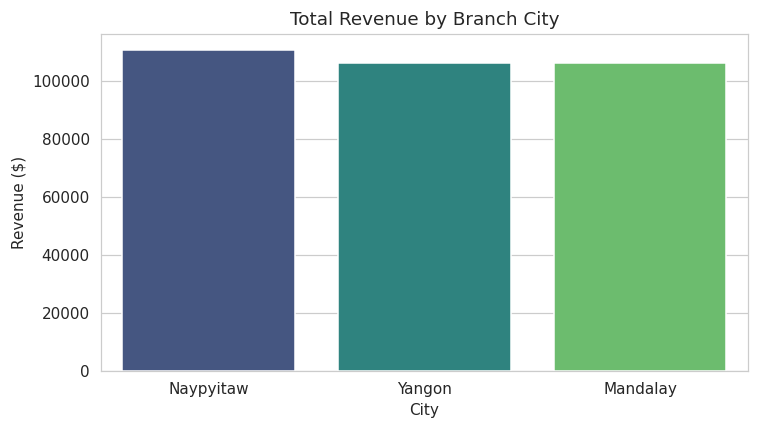

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=branch_perf, x="City", y="total_revenue", hue="City", palette="viridis", legend=False, ax=ax)
ax.set_title("Total Revenue by Branch City")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../images/revenue_by_branch.png")
plt.show()


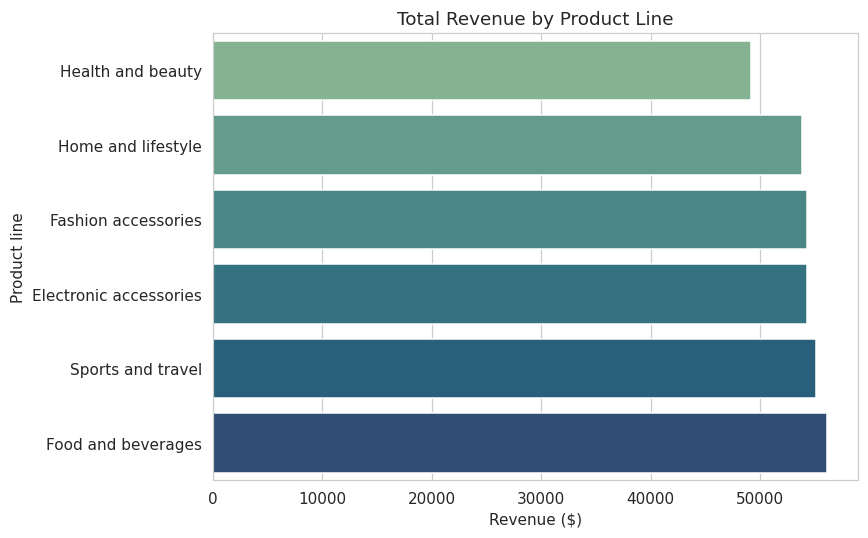

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=product_perf.sort_values("total_revenue"), y="Product line", x="total_revenue", hue="Product line", palette="crest", legend=False, ax=ax)
ax.set_title("Total Revenue by Product Line")
ax.set_xlabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../images/revenue_by_product_line.png")
plt.show()


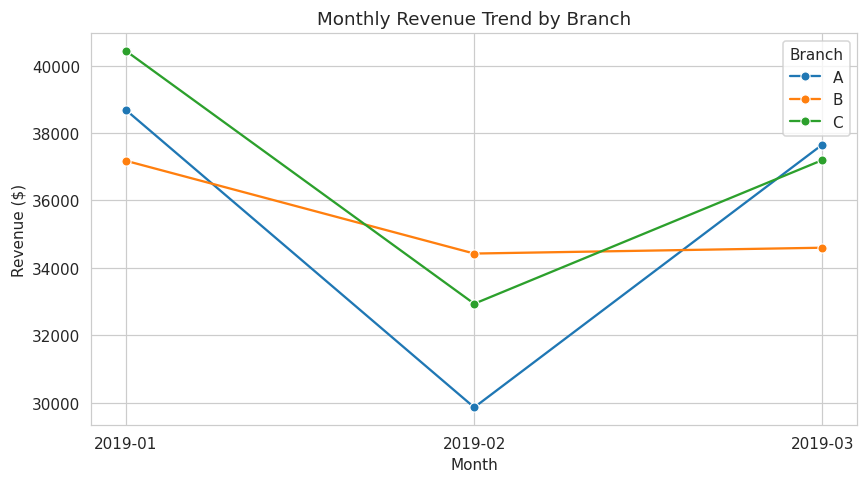

In [8]:
monthly = df.groupby(["Month", "Branch"])["Total"].sum().reset_index()
fig, ax = plt.subplots(figsize=(8,4.5))
sns.lineplot(data=monthly, x="Month", y="Total", hue="Branch", marker="o", ax=ax)
ax.set_title("Monthly Revenue Trend by Branch")
ax.set_ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("../images/monthly_trend_by_branch.png")
plt.show()


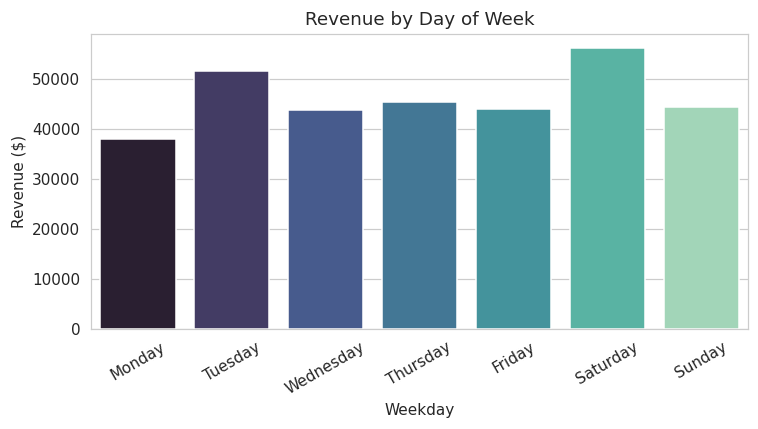

In [9]:
fig, ax = plt.subplots(figsize=(7,4))
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_rev = df.groupby("Weekday")["Total"].sum().reindex(weekday_order)
sns.barplot(x=weekday_rev.index, y=weekday_rev.values, hue=weekday_rev.index, palette="mako", legend=False, ax=ax)
ax.set_title("Revenue by Day of Week")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../images/revenue_by_weekday.png")
plt.show()


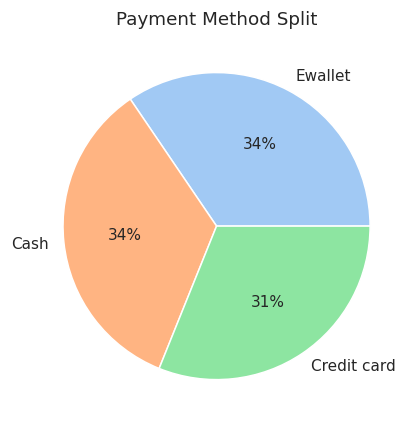

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
payment_counts = df["Payment"].value_counts()
ax.pie(payment_counts.values, labels=payment_counts.index, autopct="%1.0f%%", colors=sns.color_palette("pastel"))
ax.set_title("Payment Method Split")
plt.tight_layout()
plt.savefig("../images/payment_method_split.png")
plt.show()


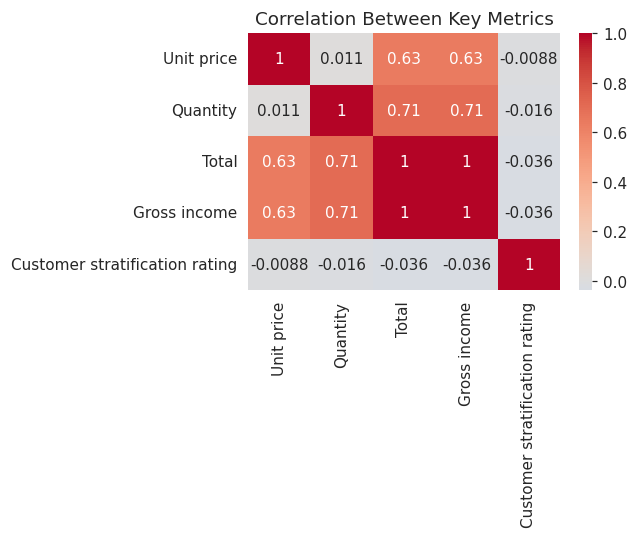

In [11]:
corr_cols = ["Unit price", "Quantity", "Total", "Gross income", "Customer stratification rating"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between Key Metrics")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png")
plt.show()


## Key Findings

- **Naypyitaw** generated the highest total revenue of the three branches, followed closely by Yangon and Mandalay -- the gap is narrow enough that branch-level differences look more like transaction-mix effects than a location clearly underperforming.
- **Food and beverages** and **Sports and travel** are the top two product lines by revenue; **Health and beauty** trails the other lines, suggesting an opportunity for targeted promotions.
- **Saturday is the strongest day** (~$56K) and **Monday the weakest** (~$38K) -- a ~48% gap, suggesting staffing and inventory should skew toward the weekend rather than being spread evenly.
- **Ewallet, cash, and credit card** are used in roughly even proportions, so no single payment rail dominates checkout -- worth keeping all three well-supported at POS.
- **Quantity and Total** are strongly correlated (as expected), while **customer rating shows little correlation** with spend -- satisfied customers don't necessarily spend more per visit, which argues against using satisfaction score alone as a spend predictor.

## How to Run

```bash
pip install pandas numpy matplotlib seaborn
jupyter notebook notebook/analysis.ipynb
```

Or run the standalone SQL queries in `sql/analysis_queries.sql` against `data/supermarket_sales.csv` loaded into any SQL engine.
